In [55]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math
all_datasets = ["esc50", "domestic"]
all_total_classes = [ 50, 34]

INDEX = 1

DATASET = all_datasets[INDEX]
TOTAL_CLASSES = all_total_classes[INDEX]

df_original = pd.read_csv(f"../results/{DATASET}_results.csv")
print(df_original.dtypes)
# 只保留特定的 classifier
df = df_original[df_original["classifier"].isin(["cosine", "euclidean", "mahalanobis"])].copy()

df["known %"] = (df["num_known"]) / (TOTAL_CLASSES)


df_mean = (
    df.groupby([
        "embedding",
        "rejection_method",
        "classifier",
        "num_known",
        "num_unknown",
        "known %"
    ])
    .mean(numeric_only=True)
    .reset_index()
)

dataset                 str
embedding               str
rejection_method        str
classifier              str
num_known             int64
num_unknown           int64
seed                  int64
threshold               str
ACC_known           float64
ACC_unknown         float64
AUROC               float64
OSCR                float64
dtype: object


In [56]:
df_mean.groupby(["embedding","known %"]).size()

embedding  known % 
clap       0.294118    9
           0.441176    9
           0.588235    9
           0.882353    9
dtype: int64

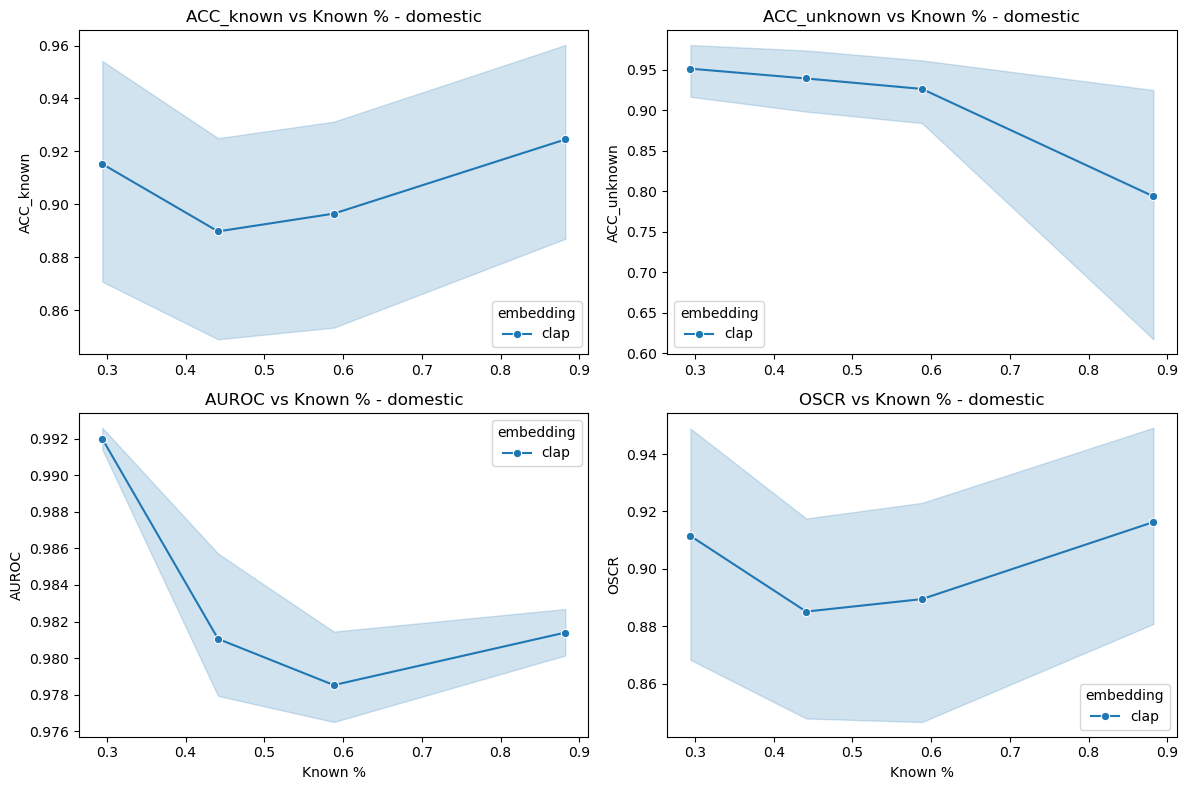

In [57]:
metrics = ["ACC_known", "ACC_unknown", "AUROC", "OSCR"]
# 创建 2x2 的子图
fig, axes = plt.subplots(2, 2, figsize=(12, 8))  # 2行2列
axes = axes.flatten()  # 展平成一维数组，方便循环

for i, m in enumerate(metrics):
    sns.lineplot(
        data=df_mean,
        x="known %",
        y=m,
        hue="embedding",
        marker="o",
        ax=axes[i]
    )
    if i < 2:
        axes[i].set_xlabel("")
    else:
        axes[i].set_xlabel("Known %")

    axes[i].set_title(f"{m} vs Known % - {DATASET}")
    
    axes[i].set_ylabel(m)

plt.tight_layout()
plt.savefig(f"{DATASET}_embedding_comparison.png", dpi=300)

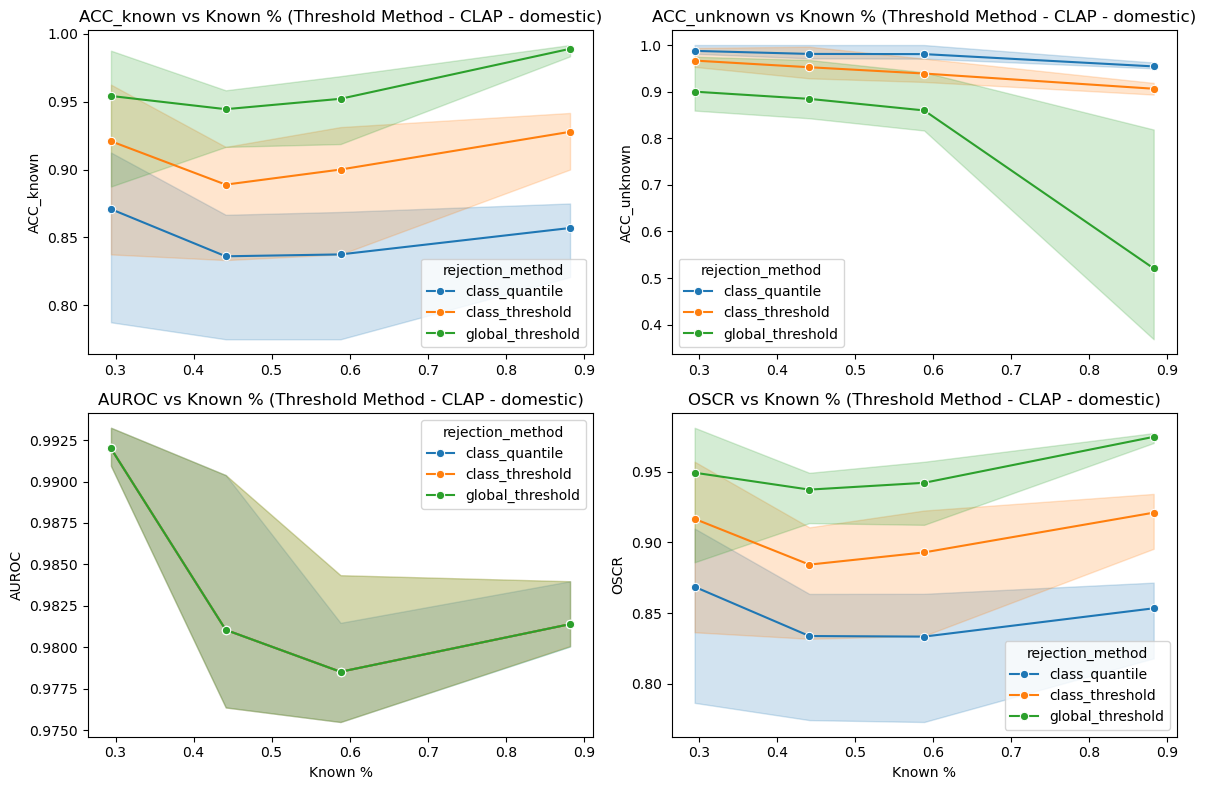

In [58]:
clap_df = df_mean[df_mean["embedding"] == "clap"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))  # 2行2列
axes = axes.flatten()  # 展平成一维数组，方便循环

for i, m in enumerate(metrics):
    
    sns.lineplot(
        data=clap_df,
        x="known %",
        y=m,
        hue="rejection_method",
        marker="o",
        ax=axes[i] 
    )
    if i < 2:
        axes[i].set_xlabel("")
    else:
        axes[i].set_xlabel("Known %")

    axes[i].set_title(f"{m} vs Known % (Threshold Method - CLAP - {DATASET})")
    
    axes[i].set_ylabel(m)

plt.tight_layout()
plt.savefig(f"{DATASET}_threshold_comparison.png", dpi=300)

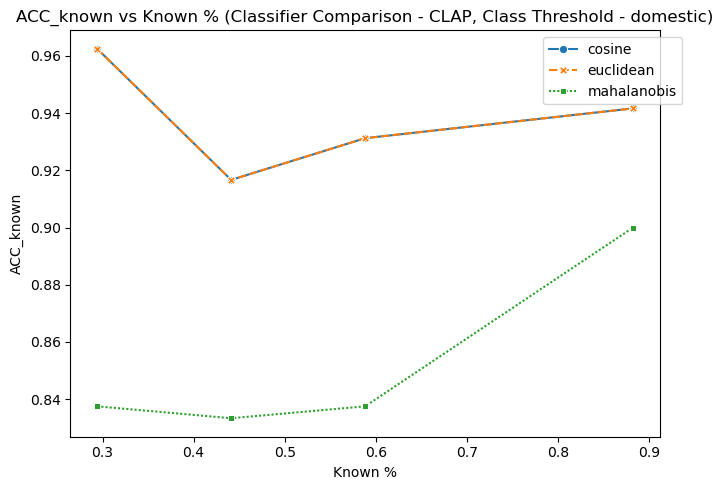

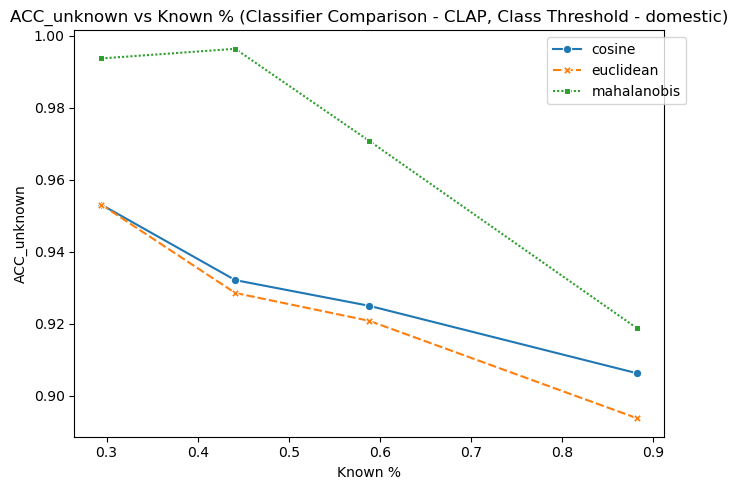

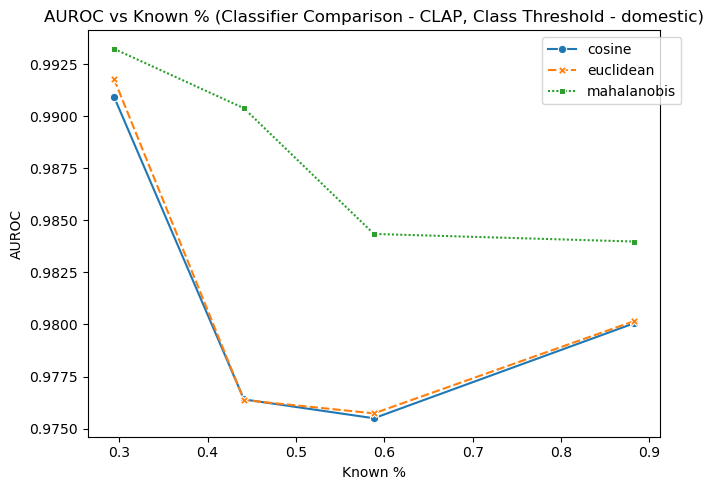

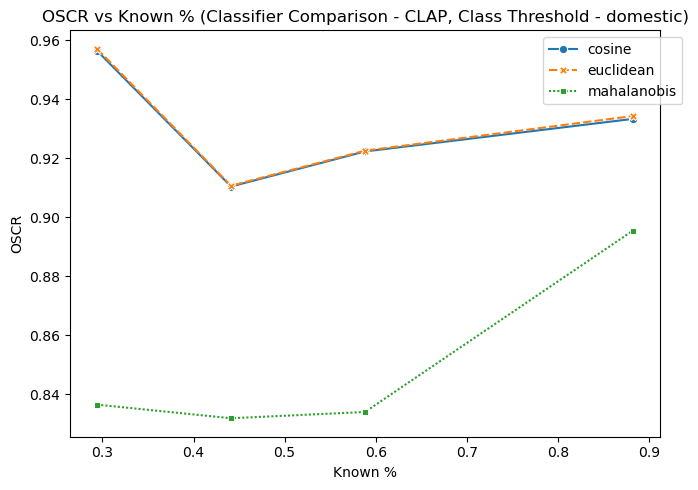

In [59]:
clap_class_df = df_mean[
    (df_mean["embedding"] == "clap") &
    (df_mean["rejection_method"] == "class_threshold")
]
markers = {
    "cosine": "o",
    "euclidean": "s",
    "mahalanobis": "D",
    "linear": "^",
    "energy": "v",
    "openmax": "X"
}

for m in metrics:

    plt.figure(figsize=(7,5))

    sns.lineplot(
        data=clap_class_df,
        x="known %",
        y=m,
        hue="classifier",
        style="classifier",
        markers=True
    )

    plt.title(f"{m} vs Known % (Classifier Comparison - CLAP, Class Threshold - {DATASET})")
    plt.ylabel(m)
    plt.xlabel("Known %")

    plt.legend(bbox_to_anchor=(1.05,1))
    plt.tight_layout()

    plt.show()

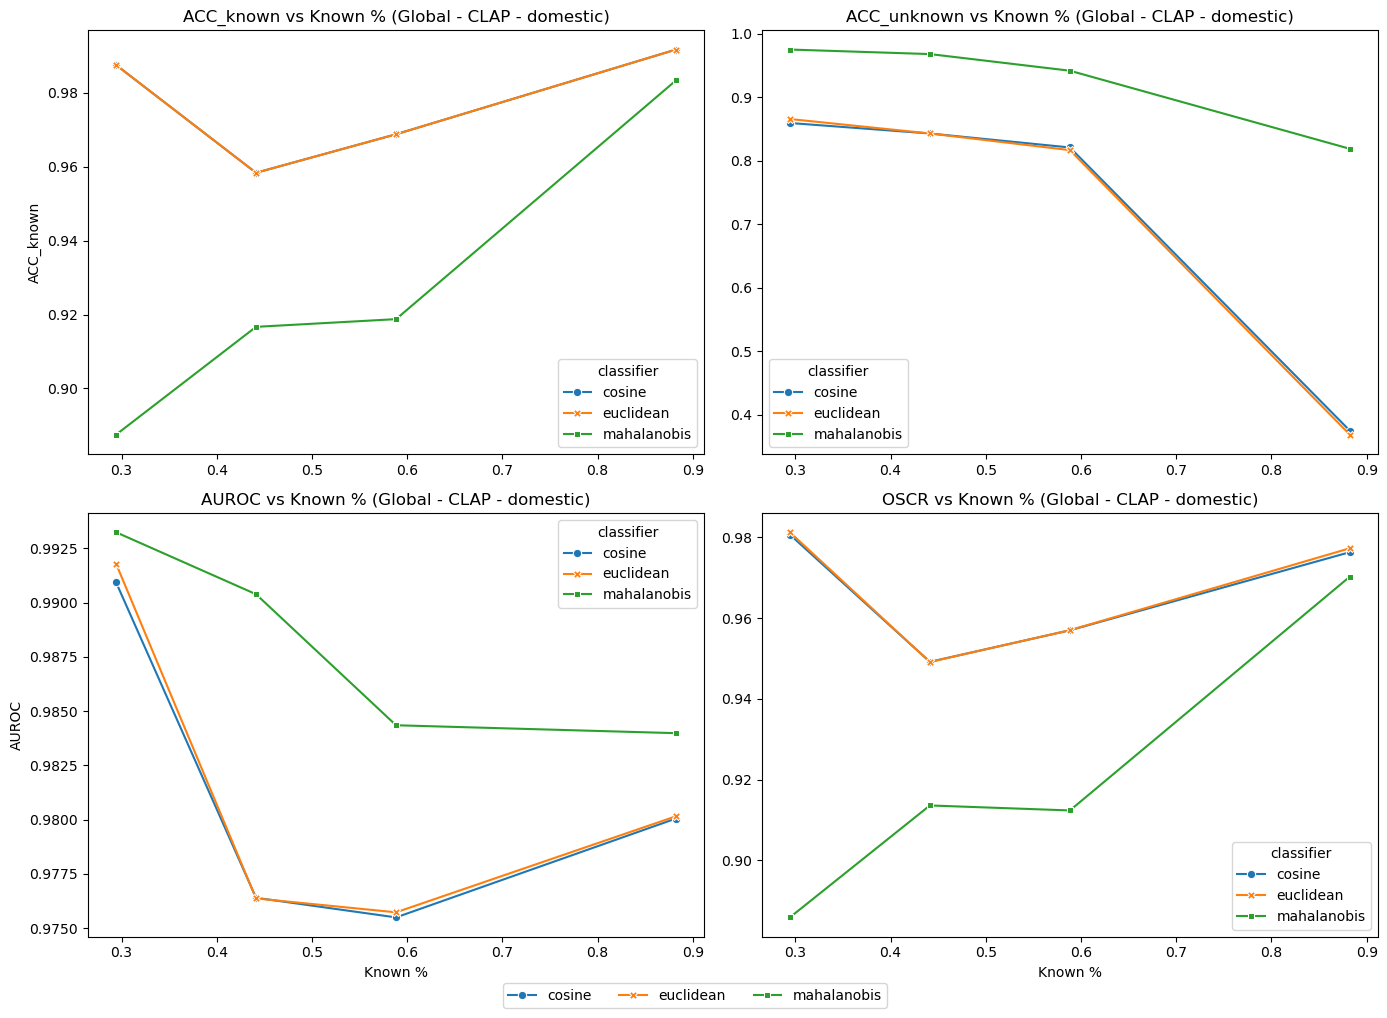

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = ["ACC_known", "ACC_unknown", "AUROC", "OSCR"]

clap_class_df = df_mean[
    (df_mean["embedding"] == "clap") &
    (df_mean["rejection_method"] == "global_threshold")
]

# 创建 2x2 子图
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# 自定义 markers
markers = {
    "cosine": "o",
    "euclidean": "s",
    "mahalanobis": "D",
    "linear": "^",
    "energy": "v",
    "openmax": "X"
}

for i, m in enumerate(metrics):
    sns.lineplot(
        data=clap_class_df,
        x="known %",
        y=m,
        hue="classifier",
        style="classifier",
        markers=True,
        dashes=False,      # 让每条线都实线
        ax=axes[i]
    )
    axes[i].set_title(f"{m} vs Known % (Global - CLAP - {DATASET})")
    
    # 只在底部子图显示 xlabel
    if i < 2:
        axes[i].set_xlabel("")
    else:
        axes[i].set_xlabel("Known %")
    
    # 只在最左边显示 ylabel
    if i % 2 == 1:
        axes[i].set_ylabel("")
    else:
        axes[i].set_ylabel(m)

# 统一图例在底部
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(labels), bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig(f"{DATASET}_clap_class_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

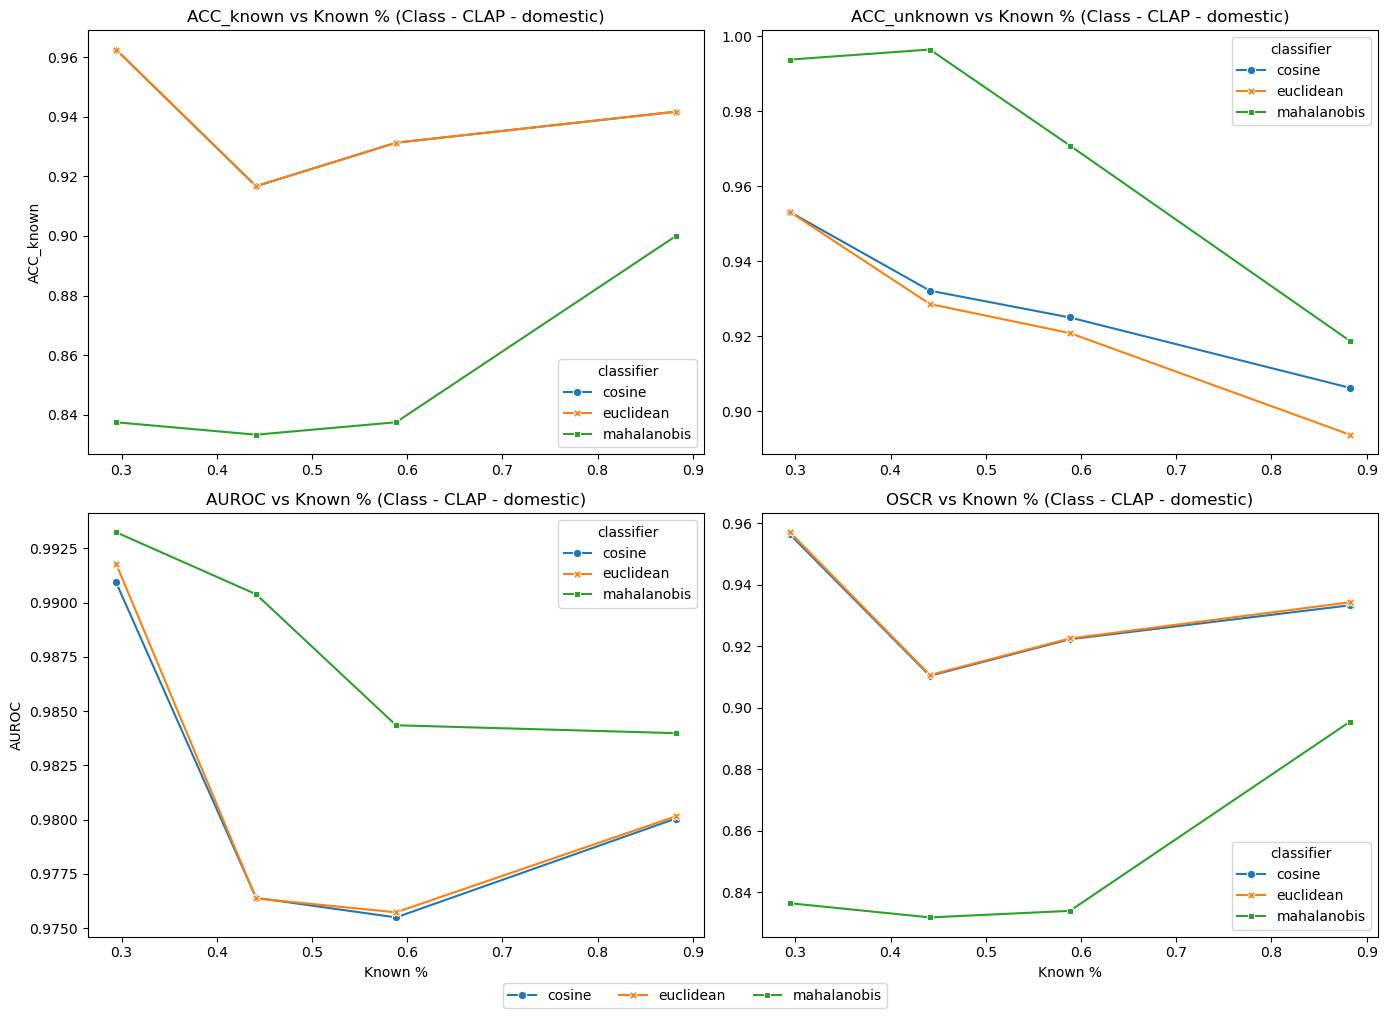

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = ["ACC_known", "ACC_unknown", "AUROC", "OSCR"]

clap_class_df = df_mean[
    (df_mean["embedding"] == "clap") &
    (df_mean["rejection_method"] == "class_threshold")
]

# 创建 2x2 子图
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# 自定义 markers
markers = {
    "cosine": "o",
    "euclidean": "s",
    "mahalanobis": "D",
    "linear": "^",
    "energy": "v",
    "openmax": "X"
}

for i, m in enumerate(metrics):
    sns.lineplot(
        data=clap_class_df,
        x="known %",
        y=m,
        hue="classifier",
        style="classifier",
        markers=True,
        dashes=False,      # 让每条线都实线
        ax=axes[i]
    )
    axes[i].set_title(f"{m} vs Known % (Class - CLAP - {DATASET})")
    
    # 只在底部子图显示 xlabel
    if i < 2:
        axes[i].set_xlabel("")
    else:
        axes[i].set_xlabel("Known %")
    
    # 只在最左边显示 ylabel
    if i % 2 == 1:
        axes[i].set_ylabel("")
    else:
        axes[i].set_ylabel(m)

# 统一图例在底部
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(labels), bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig(f"{DATASET}_clap_class_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

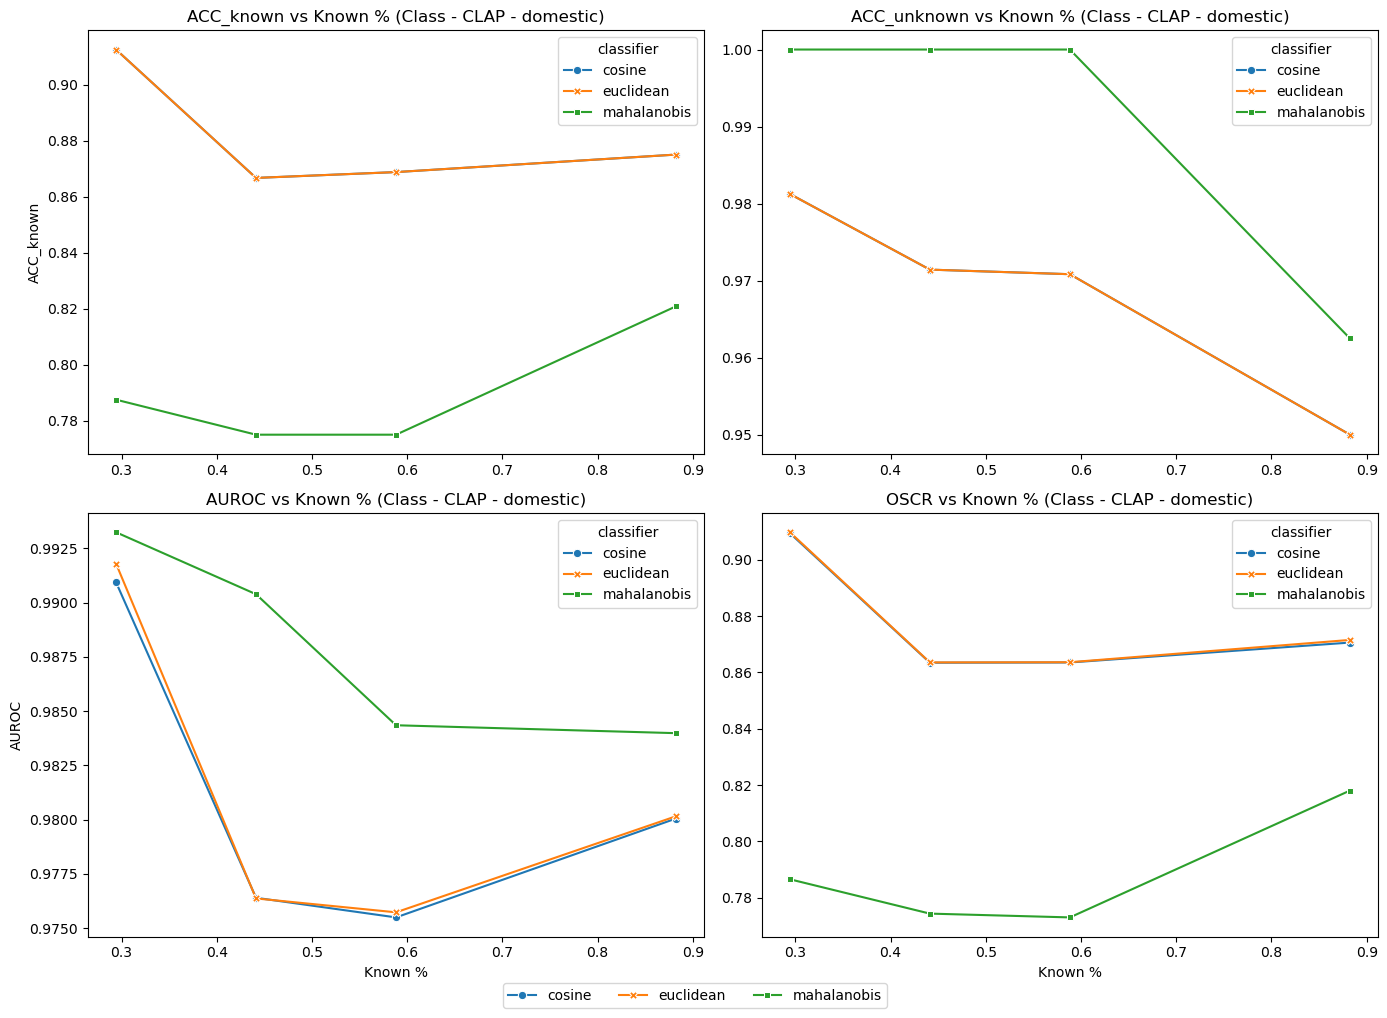

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = ["ACC_known", "ACC_unknown", "AUROC", "OSCR"]

clap_class_df = df_mean[
    (df_mean["embedding"] == "clap") &
    (df_mean["rejection_method"] == "class_quantile")
]

# 创建 2x2 子图
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# 自定义 markers
markers = {
    "cosine": "o",
    "euclidean": "s",
    "mahalanobis": "D",
    "linear": "^",
    "energy": "v",
    "openmax": "X"
}

for i, m in enumerate(metrics):
    sns.lineplot(
        data=clap_class_df,
        x="known %",
        y=m,
        hue="classifier",
        style="classifier",
        markers=True,
        dashes=False,      # 让每条线都实线
        ax=axes[i]
    )
    axes[i].set_title(f"{m} vs Known % (Class - CLAP - {DATASET})")
    
    # 只在底部子图显示 xlabel
    if i < 2:
        axes[i].set_xlabel("")
    else:
        axes[i].set_xlabel("Known %")
    
    # 只在最左边显示 ylabel
    if i % 2 == 1:
        axes[i].set_ylabel("")
    else:
        axes[i].set_ylabel(m)

# 统一图例在底部
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(labels), bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig(f"{DATASET}_clap_class_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

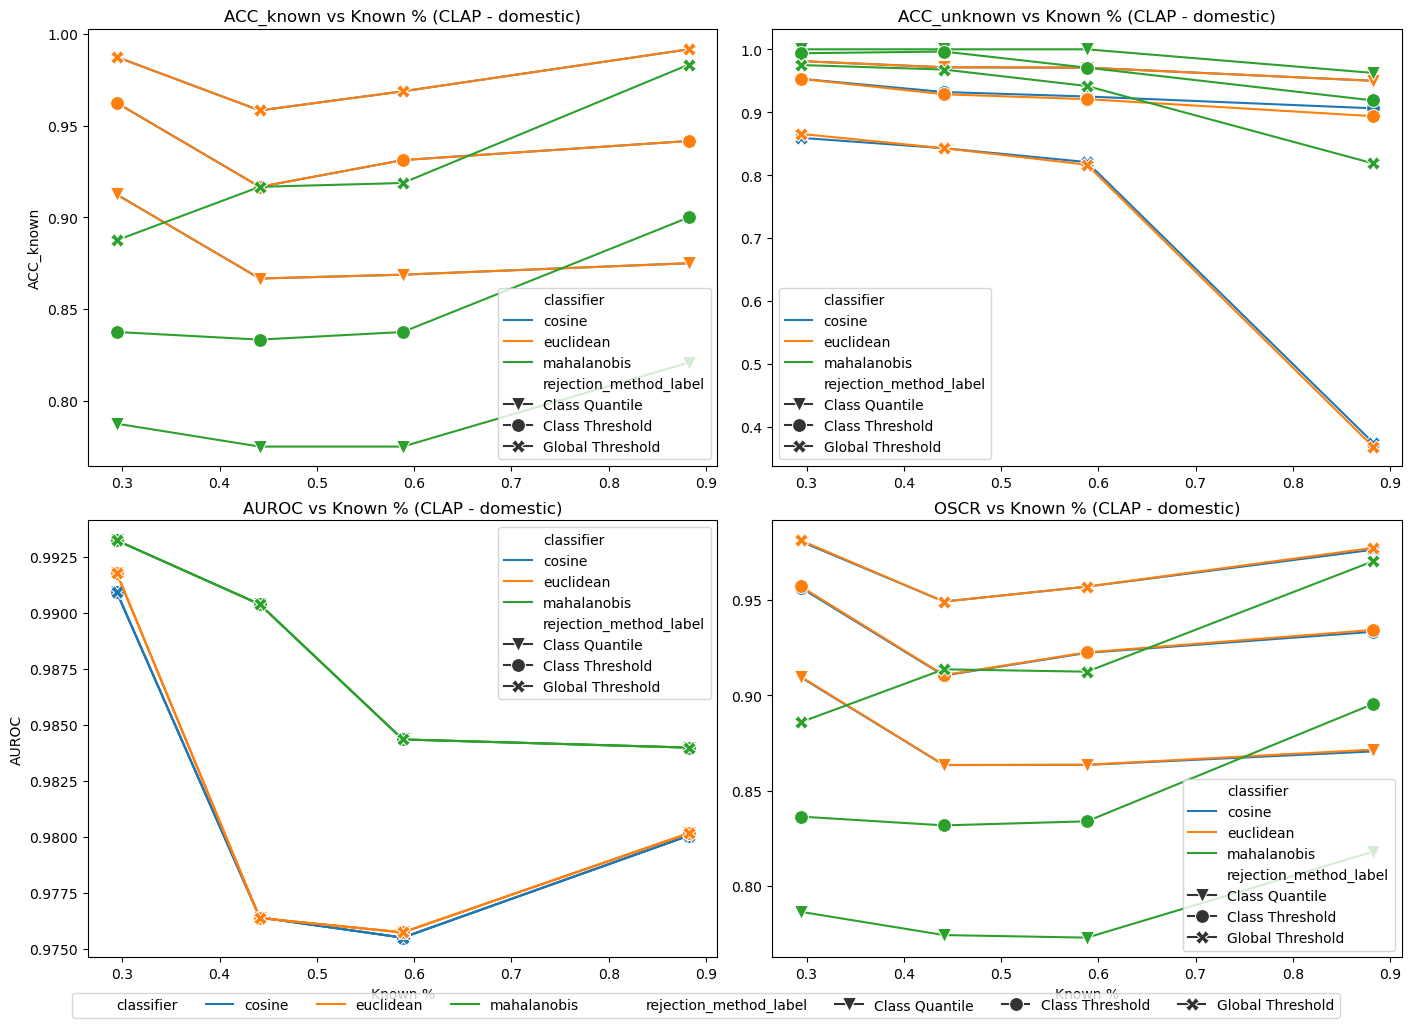

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

metrics = ["ACC_known", "ACC_unknown", "AUROC", "OSCR"]

# 只取 CLAP 的数据，并增加 rejection_method 列
clap_df = df_mean[df_mean["embedding"] == "clap"].copy()
clap_df["rejection_method_label"] = clap_df["rejection_method"].map({
    "class_threshold": "Class Threshold",
    "global_threshold": "Global Threshold",
    "class_quantile": "Class Quantile",
})

# 创建 2x2 子图
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
axes = axes.flatten()

# 自定义 markers
markers = {
    "Class Threshold": "o",
    "Global Threshold": "X",
    "Class Quantile": "v"
}

for i, m in enumerate(metrics):
    sns.lineplot(
        data=clap_df,
        x="known %",
        y=m,
        hue="classifier",                # 分类器不同颜色
        style="rejection_method_label",   # class/global 不同线型
        markers=markers,                  # 指定 marker
        dashes=False,                     # 实线
        ax=axes[i],
        markersize=10
    )
    axes[i].set_title(f"{m} vs Known % (CLAP - {DATASET})")
    
    # 只在底部子图显示 xlabel
    if i < 2:
        axes[i].set_xlabel("")
    else:
        axes[i].set_xlabel("Known %")
    
    # 只在最左边显示 ylabel
    if i % 2 == 1:
        axes[i].set_ylabel("")
    else:
        axes[i].set_ylabel(m)

# 统一图例在底部
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(labels), bbox_to_anchor=(0.5, -0.02))

# plt.tight_layout()
plt.savefig(f"{DATASET}_clap_class_vs_global_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

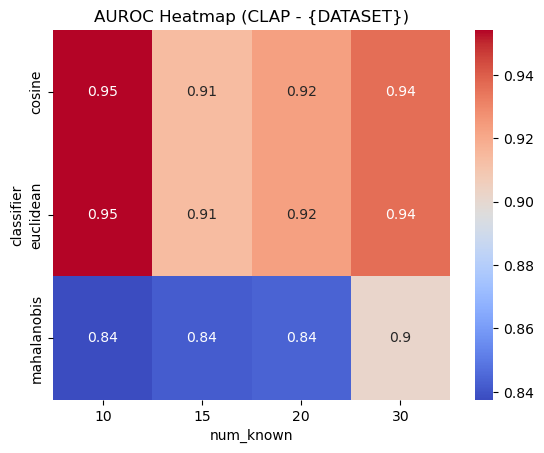

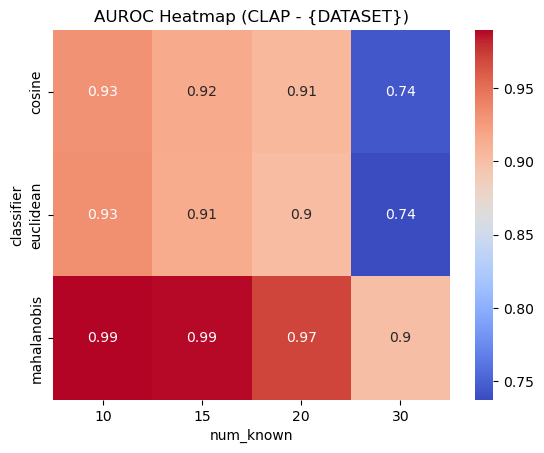

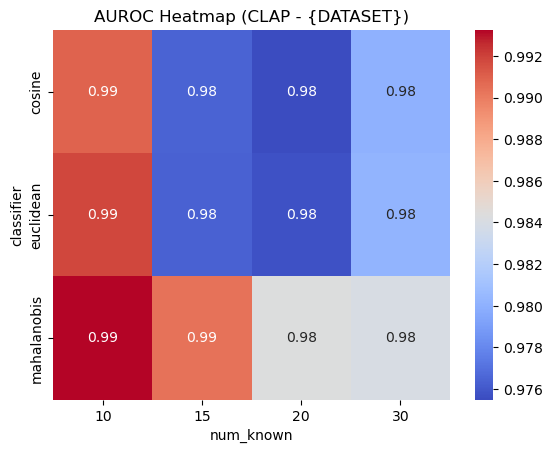

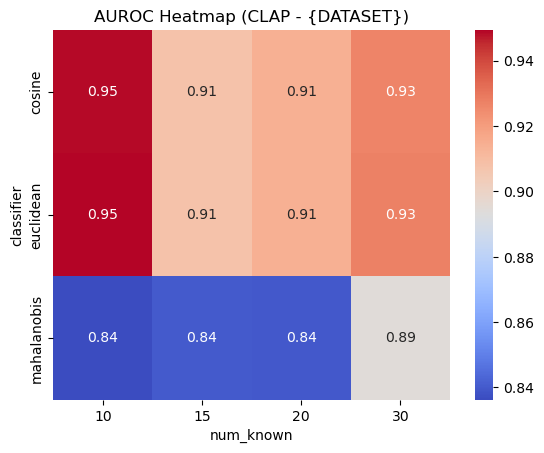

In [64]:

for m in metrics:
    pivot = clap_df.pivot_table(
        values=m,
        index="classifier",
        columns="num_known",
        aggfunc="mean"
    )
    sns.heatmap(pivot, annot=True, cmap="coolwarm")

    plt.title("AUROC Heatmap (CLAP - {DATASET})")
    plt.show()

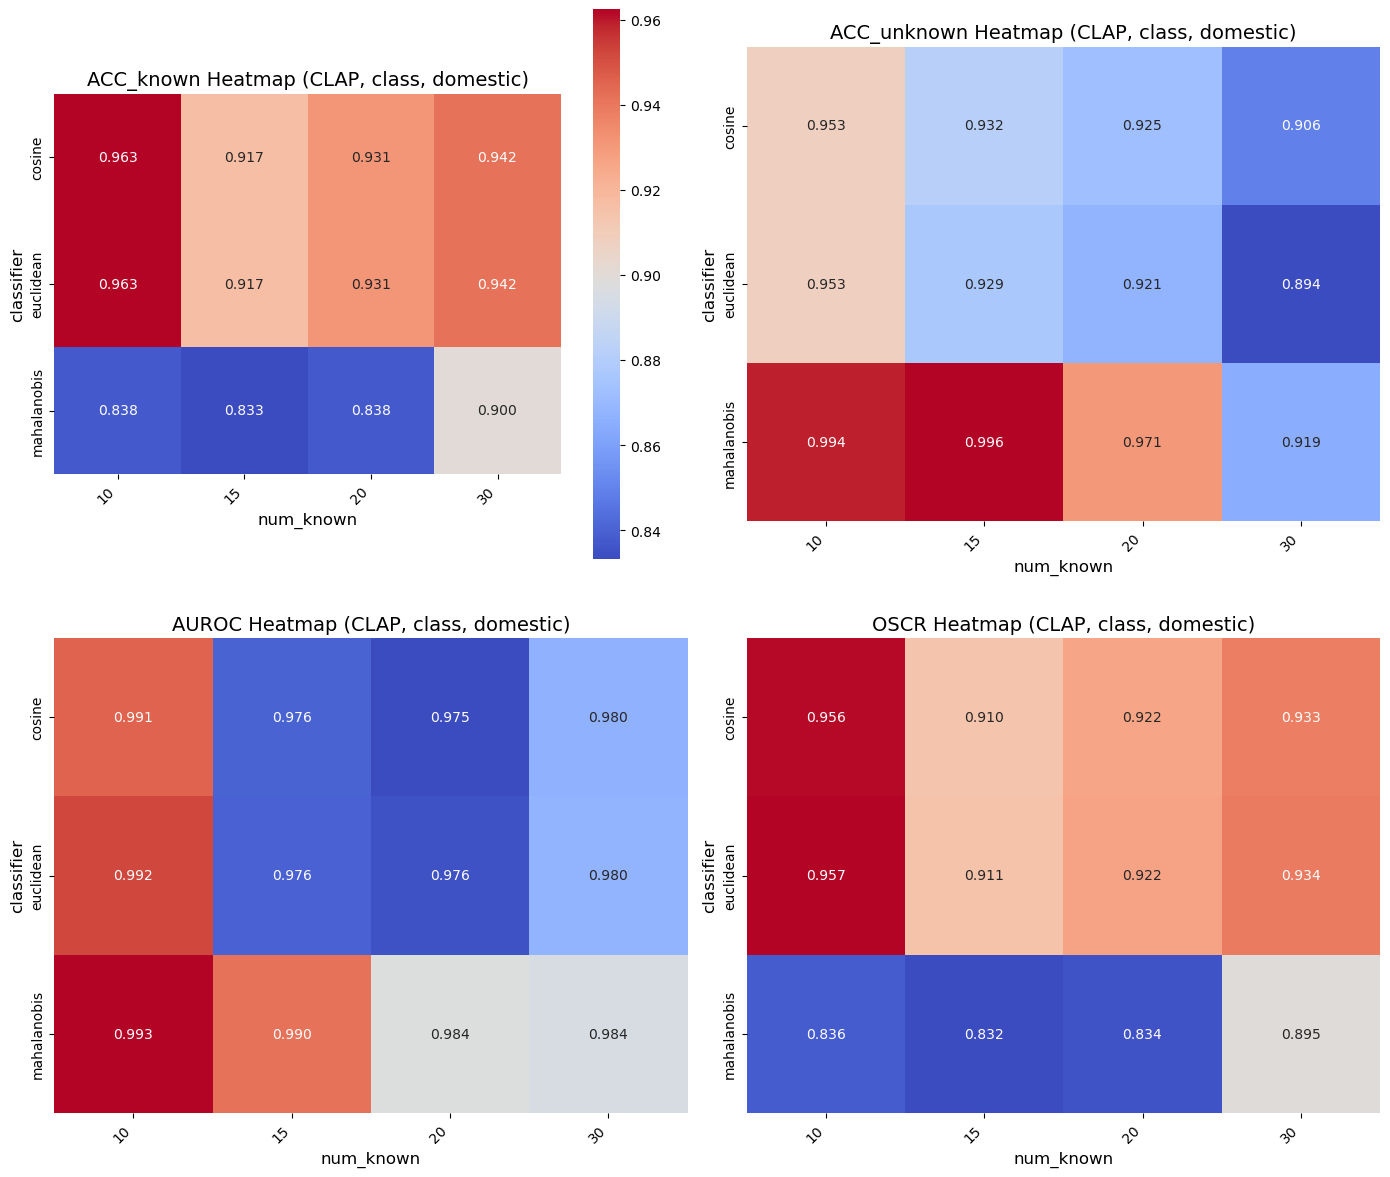

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = ["ACC_known", "ACC_unknown", "AUROC", "OSCR"]

clap_class_df = df_mean[
    (df_mean["embedding"] == "clap") &
    (df_mean["rejection_method"] == "class_threshold")
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, m in enumerate(metrics):
    pivot = clap_class_df.pivot_table(
        values=m,
        index="classifier",
        columns="num_known",
        aggfunc="mean"
    )
    
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".3f",
        cmap="coolwarm",
        ax=axes[i],
        cbar=i==0,        # 只显示一个 colorbar
        square=True
    )
    axes[i].set_title(f"{m} Heatmap (CLAP, class, {DATASET})", fontsize=14)

    # 正确设置 x/y 标签
    axes[i].set_xlabel("num_known", fontsize=12)
    axes[i].set_ylabel("classifier", fontsize=12)

    # 可选：旋转 x 轴标签，防止重叠
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig(f"{DATASET}_clap_heatmaps_class.png", dpi=300)
plt.show()

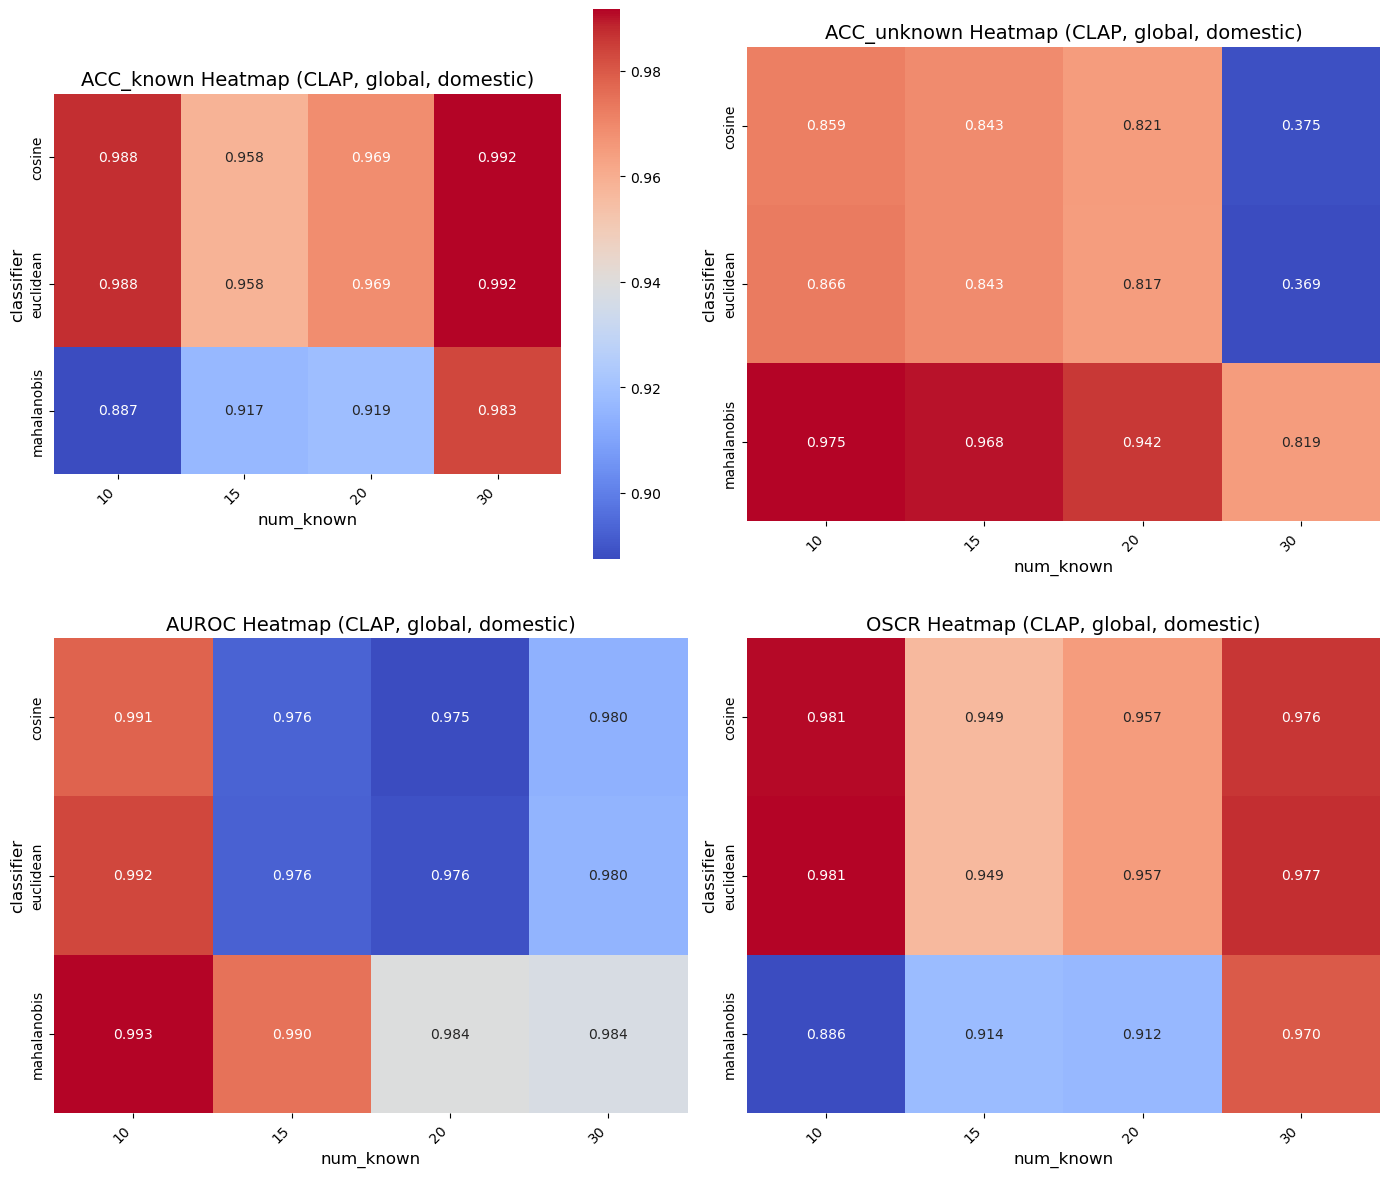

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = ["ACC_known", "ACC_unknown", "AUROC", "OSCR"]

clap_global_df = df_mean[
    (df_mean["embedding"] == "clap") &
    (df_mean["rejection_method"] == "global_threshold")
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, m in enumerate(metrics):
    pivot = clap_global_df.pivot_table(
        values=m,
        index="classifier",
        columns="num_known",
        aggfunc="mean"
    )
    
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".3f",
        cmap="coolwarm",
        ax=axes[i],
        cbar=i==0,        # 只显示一个 colorbar
        square=True
    )
    axes[i].set_title(f"{m} Heatmap (CLAP, global, {DATASET})", fontsize=14)

    # 正确设置 x/y 标签
    axes[i].set_xlabel("num_known", fontsize=12)
    axes[i].set_ylabel("classifier", fontsize=12)

    # 可选：旋转 x 轴标签，防止重叠
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig(f"{DATASET}_clap_heatmaps_global.png", dpi=300)
plt.show()